# Week 4 — Statistics, Data Visualization & EDA

**Student:** Tiwari Aman Dhananjay

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
BASE=Path.cwd().parent if Path.cwd().name=='notebook' else Path.cwd()
df=pd.read_csv(BASE/'datasets/sales_eda_raw.csv')
df.head()

,Date,Region,Product,Quantity,Unit_Price,Customers,Discount,Rating,Delivery_Days,Sales
0,2026-01-01,North,Tablet,1,700,48,12,3.7,3,700.0
1,2026-01-02,West,Monitor,5,900,102,16,4.3,4,4500.0
2,2026-01-03,East,Monitor,1,180,45,15,3.1,4,180.0
3,2026-01-04,South,Tablet,5,900,99,2,4.8,4,4500.0
4,2026-01-05,South,Headphones,5,120,66,17,4.2,2,600.0


## Tasks 1–2 — Statistical Analysis

In [19]:
sales=df['Sales'].dropna()
print('Mean:',sales.mean())
print('Median:',sales.median())
print('Mode:',sales.mode().iloc[0])
print('Variance:',sales.var())
print('Standard Deviation:',sales.std())

Mean: 1832.75
Median: 1000.0
Mode: 700.0
Variance: 10978952.87815126
Standard Deviation: 3313.4502981259975


## Task 3 — Correlation & Probability

In [20]:
clean=df.copy()
clean['Region']=clean['Region'].astype(str).str.strip().str.title()
clean['Product']=clean['Product'].astype(str).str.strip().str.title()
clean['Sales']=clean['Sales'].fillna(clean['Sales'].median())
clean['Rating']=clean['Rating'].fillna(clean['Rating'].median())
clean=clean.drop_duplicates().reset_index(drop=True)
clean['Quantity']=clean['Quantity'].clip(1,10)
clean['Sales']=clean['Quantity']*clean['Unit_Price']
print('Correlation:',clean['Quantity'].corr(clean['Sales']))
print('Probability Sales > Median:',(clean['Sales']>clean['Sales'].median()).mean())

Correlation: 0.5023802687083032
Probability Sales > Median: 0.49166666666666664


## Task 4 — Outlier Detection (IQR)

In [11]:
q1,q3=clean['Sales'].quantile([.25,.75]); iqr=q3-q1
outliers=clean[(clean['Sales']<q1-1.5*iqr)|(clean['Sales']>q3+1.5*iqr)]
outliers

,Date,Region,Product,Quantity,Unit_Price,Customers,Discount,Rating,Delivery_Days,Sales
56,2026-02-26,East,Monitor,6,900,65,16,4.5,1,5400
77,2026-03-19,North,Laptop,6,900,107,1,4.1,5,5400
90,2026-04-01,South,Phone,10,900,114,20,3.7,7,9000


## Tasks 5–6 — Visualization

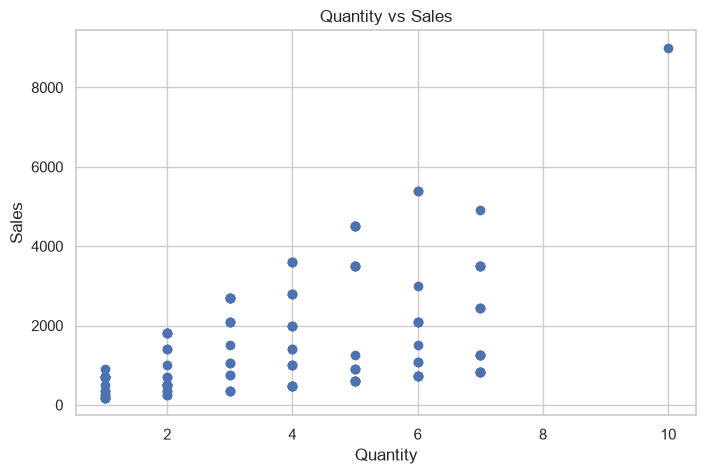

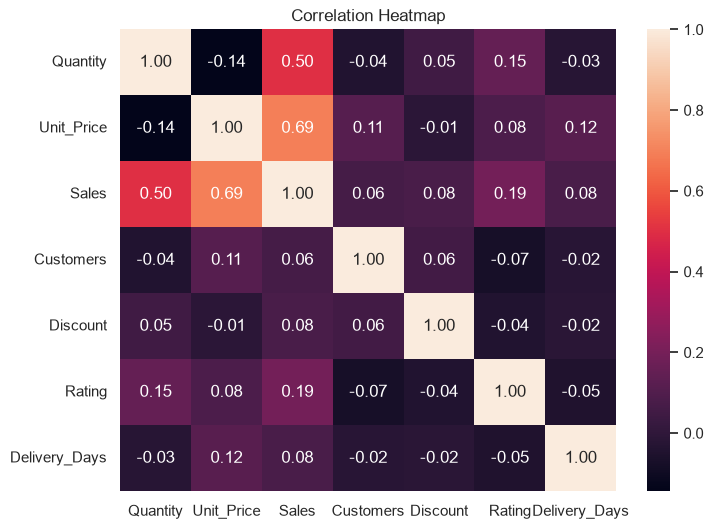

In [12]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8,5)); plt.scatter(clean['Quantity'],clean['Sales']); plt.title('Quantity vs Sales'); plt.xlabel('Quantity'); plt.ylabel('Sales'); plt.show()
plt.figure(figsize=(8,6)); sns.heatmap(clean[['Quantity','Unit_Price','Sales','Customers','Discount','Rating','Delivery_Days']].corr(),annot=True,fmt='.2f'); plt.title('Correlation Heatmap'); plt.show()

## Task 7 — EDA Inspection & Cleaning

In [13]:
print('Shape before:',df.shape)
print('Columns:',df.columns.tolist())
print('Missing values:\n',df.isna().sum())
print('Duplicates:',df.duplicated().sum())
print('Shape after:',clean.shape)
clean.to_csv(BASE/'outputs'/'eda'/'notebook_cleaned_dataset.csv',index=False)

Shape before: (122, 10)
Columns: ['Date', 'Region', 'Product', 'Quantity', 'Unit_Price', 'Customers', 'Discount', 'Rating', 'Delivery_Days', 'Sales']
Missing values:
 Date             0
Region           0
Product          0
Quantity         0
Unit_Price       0
Customers        0
Discount         0
Rating           3
Delivery_Days    0
Sales            2
dtype: int64
Duplicates: 2
Shape after: (120, 10)


## Tasks 8–9 — Insights & Recommendations

In [14]:
region_sales=clean.groupby('Region')['Sales'].sum().sort_values(ascending=False)
product_sales=clean.groupby('Product')['Sales'].sum().sort_values(ascending=False)
print('Top Region:',region_sales.index[0])
print('Top Product:',product_sales.index[0])
print('Correlation:',clean['Quantity'].corr(clean['Sales']))
print('Recommendation 1: prioritize the highest-sales region.')
print('Recommendation 2: review strategy for the highest-sales product.')
print('Recommendation 3: investigate outliers before predictive modeling.')

Top Region: East
Top Product: Monitor
Correlation: 0.5023802687083032
Recommendation 1: prioritize the highest-sales region.
Recommendation 2: review strategy for the highest-sales product.
Recommendation 3: investigate outliers before predictive modeling.
